# 03 — Promo calendar + lag imputation

Build (Customer × Brand × YearMonth) promo calendar from TPR chargebacks. For TPR rows with no MM/YY in the description, impute promo_ym by subtracting the median doc_date lag.

**Upstream:** `tpr_with_brand.parquet` from `02_brand.ipynb`.

**Outputs:**
- `promo_cal.parquet` — unique `(CUSTNMBR, brand, promo_ym)` tuples. `promo_ym` is serialized as `'YYYY-MM'` string; round-trip via `pd.PeriodIndex(..., freq='M')`.
- `promo_lag_meta.parquet` — one-row table holding the fitted `median_lag_days` so downstream steps don't re-fit.

**Promotes to:** `src/promo_cal.py` once coverage + lag shape check pass.

## 1. Imports

In [1]:
import re
import sys
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == 'pipeline' else Path.cwd()
ART = ROOT / 'pipeline' / 'artifacts'
ART.mkdir(parents=True, exist_ok=True)

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

## 2. Load upstream

In [2]:
tpr = pd.read_parquet(ART / 'tpr_with_brand.parquet')
print(f'tpr: {tpr.shape}')
print(f'columns: {list(tpr.columns)}')
print(f'brand null: {tpr["brand"].isna().sum()}  ({tpr["brand"].isna().mean()*100:.1f}%)')

tpr: (6868, 14)
columns: ['Location Code', 'Salesperson ID', 'Customer Number', 'City from Sales Transaction', 'State from Sales Transaction', 'SOP Type', 'SOP Number', 'Customer PO Number', 'Document Date', 'Cause Code', 'Cause Code Desc', 'Item Description', 'Extended Price', 'brand']
brand null: 849  (12.4%)


## 3. Do the work

rows with MM/YY in description : 6,737 / 6,868  (98.1%)

lag_days stats (doc_date - promo_start, on the 6,737 labeled rows):
count    6737.000000
mean      153.799614
std        99.540780
min        -3.000000
25%        89.000000
50%       128.000000
75%       194.000000
max      1074.000000

median lag = 128 days   mean = 154 days


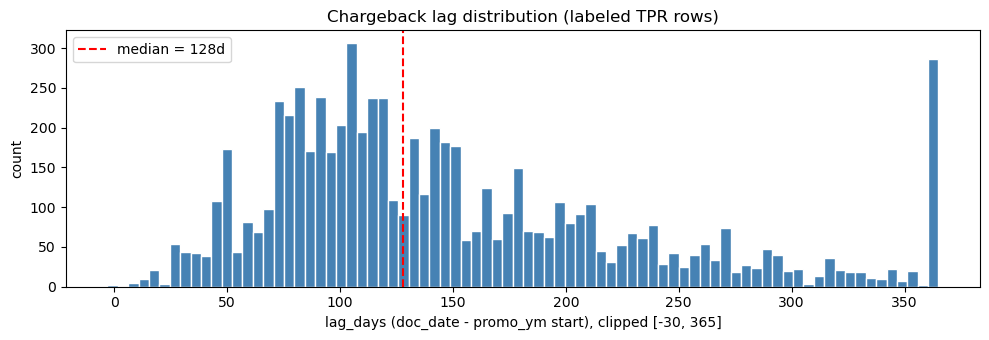


promo_ym coverage:
  regex alone            :  98.1%
  regex + lag fallback   : 100.0%
  delta                  : +1.9pp

promo_cal rows: 1,391
unique customers : 71
unique brands    : 9
unique months    : 47


In [3]:
# ---- Step A: extract embedded MM/YY from Item Description -------------------
# Covers "03/23", "12/24", etc. Only 20xx years.
MMYY = re.compile(r'\b(0[1-9]|1[0-2])/(2[0-9])\b')


def extract_promo_ym(desc):
    """Return pd.Period('YYYY-MM', 'M') if the description embeds an MM/YY, else None."""
    if pd.isna(desc):
        return None
    m = MMYY.search(str(desc))
    if not m:
        return None
    mm, yy = m.group(1), m.group(2)
    return pd.Period(f'20{yy}-{mm}', freq='M')


tpr['promo_ym_raw'] = tpr['Item Description'].apply(extract_promo_ym)
tpr['doc_ym']       = pd.to_datetime(tpr['Document Date']).dt.to_period('M')

raw_cov = tpr['promo_ym_raw'].notna().mean()
print(f'rows with MM/YY in description : {tpr["promo_ym_raw"].notna().sum():,} / {len(tpr):,}  ({raw_cov*100:.1f}%)')

# ---- Step B: learn median lag (doc_date - promo_start) on the labeled subset
has_ym = tpr[tpr['promo_ym_raw'].notna()].copy()
has_ym['promo_start'] = has_ym['promo_ym_raw'].apply(lambda p: p.to_timestamp())
has_ym['lag_days'] = (pd.to_datetime(has_ym['Document Date']) - has_ym['promo_start']).dt.days

median_lag = has_ym['lag_days'].median()
mean_lag   = has_ym['lag_days'].mean()
print(f'\nlag_days stats (doc_date - promo_start, on the {len(has_ym):,} labeled rows):')
print(has_ym['lag_days'].describe().to_string())
print(f'\nmedian lag = {median_lag:.0f} days   mean = {mean_lag:.0f} days')

# Plot clipped distribution — sanity check the median
fig, ax = plt.subplots(figsize=(10, 3.5))
ax.hist(has_ym['lag_days'].clip(-30, 365), bins=80, color='steelblue', edgecolor='white')
ax.axvline(median_lag, color='red', linestyle='--', label=f'median = {median_lag:.0f}d')
ax.set_xlabel('lag_days (doc_date - promo_ym start), clipped [-30, 365]')
ax.set_ylabel('count')
ax.set_title('Chargeback lag distribution (labeled TPR rows)')
ax.legend()
plt.tight_layout()
plt.show()


# ---- Step C: impute promo_ym via lag fallback for the unlabeled rows --------
def estimate_promo_ym_from_doc(doc_date, lag_days=median_lag):
    """promo_ym ≈ doc_date − median_lag, rounded to month."""
    if pd.isna(doc_date):
        return pd.NaT
    est = pd.to_datetime(doc_date) - pd.Timedelta(days=lag_days)
    return pd.Period(est, freq='M')


tpr['promo_ym'] = tpr['promo_ym_raw']
need_fallback = tpr['promo_ym'].isna()
tpr.loc[need_fallback, 'promo_ym'] = (
    tpr.loc[need_fallback, 'Document Date'].apply(estimate_promo_ym_from_doc)
)

final_cov = tpr['promo_ym'].notna().mean()
print(f'\npromo_ym coverage:')
print(f'  regex alone            : {raw_cov*100:5.1f}%')
print(f'  regex + lag fallback   : {final_cov*100:5.1f}%')
print(f'  delta                  : +{(final_cov-raw_cov)*100:.1f}pp')

# ---- Step D: build the (customer × brand × ym) calendar ---------------------
promo_cal = (
    tpr.dropna(subset=['Customer Number', 'brand', 'promo_ym'])
       [['Customer Number', 'brand', 'promo_ym']]
       .drop_duplicates()
       .reset_index(drop=True)
)
promo_cal['Customer Number'] = promo_cal['Customer Number'].astype(str)
# Normalize column names for downstream joins (cust_num matches neither sales nor chargebacks,
# so rename to CUSTNMBR which matches sales).
promo_cal = promo_cal.rename(columns={'Customer Number': 'CUSTNMBR'})

print(f'\npromo_cal rows: {len(promo_cal):,}')
print(f'unique customers : {promo_cal["CUSTNMBR"].nunique():,}')
print(f'unique brands    : {promo_cal["brand"].nunique():,}')
print(f'unique months    : {promo_cal["promo_ym"].nunique():,}')

## 4. Validate

In [4]:
# ---- Month range coverage ----------------------------------------------------
print('Promo months per brand:')
print(promo_cal.groupby('brand')['promo_ym'].nunique().sort_values(ascending=False).to_string())

print('\nMonth range spanned by the calendar:')
print(f'  min : {promo_cal["promo_ym"].min()}')
print(f'  max : {promo_cal["promo_ym"].max()}')

# ---- Rows per customer (spot check) -----------------------------------------
per_cust = promo_cal.groupby('CUSTNMBR').size().describe()
print('\nPromo-tuples per customer:')
print(per_cust.to_string())

# ---- Dup check: should be zero (we dropped duplicates) ----------------------
dups = promo_cal.duplicated(subset=['CUSTNMBR', 'brand', 'promo_ym']).sum()
print(f'\nduplicate (CUSTNMBR, brand, promo_ym) tuples: {dups}')

# ---- Sanity: top 10 promo_ym values (should cluster around 2023-2025) ------
print('\nTop 10 promo_ym counts:')
print(promo_cal['promo_ym'].value_counts().head(10).to_string())

# ---- Spot check: one brand's calendar for the top customer ------------------
top_brand_cust = (
    promo_cal.groupby(['CUSTNMBR', 'brand']).size()
             .sort_values(ascending=False).head(5)
)
print('\nTop 5 (customer, brand) promo-month counts:')
print(top_brand_cust.to_string())

Promo months per brand:
brand
tiger balm               45
ginger chew              42
ginger honey crystals    34
am gsg                   31
bee & flower             29
ginseng                  28
cofixrx                  13
hans honey               11
azzurx                    5

Month range spanned by the calendar:
  min : 2021-01
  max : 2025-12

Promo-tuples per customer:
count     71.000000
mean      19.591549
std       21.954223
min        1.000000
25%        6.000000
50%       12.000000
75%       25.500000
max      143.000000

duplicate (CUSTNMBR, brand, promo_ym) tuples: 0

Top 10 promo_ym counts:
promo_ym
2025-01    60
2024-11    59
2024-07    58
2025-04    54
2025-05    46
2024-01    45
2024-10    45
2025-03    45
2023-07    44
2024-05    44
Freq: M

Top 5 (customer, brand) promo-month counts:
CUSTNMBR  brand      
WAO556A   tiger balm     34
MTA592A   tiger balm     34
MPE087A   ginger chew    33
WAO556A   ginger chew    33
MIM033A   tiger balm     32


## 5. Save downstream artifact

In [5]:
# promo_ym is pd.Period -> parquet can't serialize directly; cast to string 'YYYY-MM'.
# Downstream code can round-trip via pd.PeriodIndex(..., freq='M').
promo_cal_out = promo_cal.copy()
promo_cal_out['promo_ym'] = promo_cal_out['promo_ym'].astype(str)

promo_cal_out.to_parquet(ART / 'promo_cal.parquet')
print(f'promo_cal  {promo_cal_out.shape}  -> promo_cal.parquet')

# Also persist the learned median lag so downstream steps (tagging, backfilling)
# can reuse the same number without re-fitting.
lag_meta = pd.DataFrame({'key': ['median_lag_days'], 'value': [median_lag]})
lag_meta.to_parquet(ART / 'promo_lag_meta.parquet')
print(f'lag_meta   {lag_meta.shape}  -> promo_lag_meta.parquet  (median_lag={median_lag:.0f}d)')

promo_cal  (1391, 3)  -> promo_cal.parquet
lag_meta   (1, 2)  -> promo_lag_meta.parquet  (median_lag=128d)


## 6. Promote

Once validation above looks right, extract the core logic into `src/promo_cal.py` and replace the inline code here with `from src.<module> import ...`. Downstream dev notebooks can then import the same function.